# Marching Qubes Vertex Classification with EHands and QCrank
## Brandon Watanabe


In [1]:
# imports, part 1
import numpy as np
import matplotlib.pyplot as plt
import math
from math import pi
import random
import sys
from dotenv import load_dotenv
import os
from pathlib import Path
from collections import defaultdict

import qiskit
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import Statevector, Operator, Pauli
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_distribution, array_to_latex
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.options.sampler_options import SamplerOptions

print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.3.0


In [2]:
# Adapted from Chris Pestano's QSobel
load_dotenv()
data_encoder_circuits_path = os.getenv('DATA_ENCODER_CIRCUITS_PATH')

if data_encoder_circuits_path is None:
    raise EnvironmentError("DATA_ENCODER_CIRCUITS_PATH environment variable is not set. Please set it to the path of data-encoder-circuits.")

print(f"Using DATA_ENCODER_CIRCUITS_PATH from environment variable: {data_encoder_circuits_path}")
circuits_path = data_encoder_circuits_path

# Add to sys.path if not already present
if circuits_path not in sys.path:
    sys.path.insert(0, circuits_path)

print(f"Added to sys.path: {circuits_path}")
print(f"Current working directory: {os.getcwd()}")

from datacircuits.ParametricQCrankV2 import ParametricQCrankV2 as QCrankV2, analyze_qcrank_residuals

Using DATA_ENCODER_CIRCUITS_PATH from environment variable: C:\Users\burne\Documents\SchoolWork\QC-Classes\References\repos\data-encoder-circuits
Added to sys.path: C:\Users\burne\Documents\SchoolWork\QC-Classes\References\repos\data-encoder-circuits
Current working directory: C:\Users\burne\Documents\SchoolWork\QC-Classes\Coding Projects\Marching-Qubes-Thesis


In [3]:
sim = AerSimulator()

print(sim)
print(f"\nConfiguration: {sim.configuration()}")

if hasattr(sim, 'available_methods'):
    print(f"Available methods: {sim.available_methods()}")
else:
    print(sim.configuration())

if hasattr(sim, 'available_devices'):
    print(f"Available devices: {sim.available_devices()}")
else:
    print(sim.configuration())   

AerSimulator('aer_simulator')

Configuration: <qiskit_aer.backends.backendconfiguration.AerBackendConfiguration object at 0x000001D83039AFD0>
Available methods: ('automatic', 'statevector', 'density_matrix', 'stabilizer', 'matrix_product_state', 'extended_stabilizer', 'unitary', 'superop')
Available devices: ('CPU',)


In [4]:
def run_sim_job(qc, n_shots = 2**8, verbose=False):
    """ 
    Run a quantum circuit on the simulator and return the counts.
    
    :param qc: QuantumCircuit to run
    :param n_shots: Number of shots to run the circuit for
    :param verbose: If True, print the circuit and counts

    :return: Counts of the measurement outcomes
    """

    transpiled_circuit = transpile(qc, sim)    
    job = sim.run(transpiled_circuit, shots=n_shots)
    result = job.result()
    
    # Get counts and output distribution
    counts = result.get_counts(transpiled_circuit)

    if verbose:
        print("Circuit before transpilation")
        display(qc.draw('mpl'))
        print("Circuit after transpilation")
        display(transpiled_circuit.draw('mpl', style="iqp"))

        print("Counts:")
        print(counts)
        display(plot_distribution(counts))

    return counts

In [5]:
def display_statevector(qc):
    """
    Display the statevector, unitary matrix, and Bloch sphere representation of a quantum circuit.

    :param qc: QuantumCircuit to analyze

    :return: Statevector of the quantum circuit
    """
    # Get Statevector
    state = Statevector.from_instruction(qc)

    # Display Statevector
    print("\nStatevector:")
    display(state.draw("latex"))

    matrix_form = np.array(state).reshape(-1, 1)
    print("\nStatevector as a matrix:")
    display(array_to_latex(matrix_form))
    
    # Display the Unitary Matrix
    print("Unitary matrix:")
    display(Operator(qc).draw("latex"))

    # Display Bloch Sphere
    display(plot_bloch_multivector(state))

    return state

In [6]:
def plot_residuals(actual, theory, title, x_label, y_label, legend):
    # plot residual
    plt.scatter(theory, actual, label=legend)
    plt.plot(theory, theory, color='red', label='Ideal')
    # calculate slope of line of best fit
    coefficients = np.polyfit(theory, actual, 1)
    print(f"Slope of line of best fit: {coefficients[0]:.4f}")

    plt.xlabel(x_label)    
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()

    plt.show()

In [7]:
def ehands_addition(qc, q_a, q_b, weight, negation=False):
    """ 
    Perform an EHands addition of two qubits with a given weight and optional negation.

    :param qc: QuantumCircuit to which the addition will be applied
    :param q_a: Index of the first qubit
    :param q_b: Index of the second qubit
    :param weight: Weight for the addition (between 0 and 1)
    :param negation: If True, negate the second qubit before addition

    :return: QuantumCircuit with the eHANDS addition applied   
    """
    alpha = np.arccos(1 - 2 * weight)

    qc_add = QuantumCircuit(2)

    if negation:
        qc_add.x(1)

    qc_add.rz(pi/2, 1)
    qc_add.cx(0, 1)
    qc_add.ry(alpha/2, 0)
    qc_add.cx(1, 0) 
    qc_add.ry(-alpha/2, 0)

    return qc.compose(qc_add, qubits=[q_a, q_b])


## Test of addition and subtraction using EHands EVEN encoding and decoding on 2 qubits 

In [8]:
def test_ehands_addition(x0, x1, negation):
    """
    Test the EHANDS addition circuit by encoding two values into qubits, finding the optimal weight for the addition, 
    applying the EHANDS addition, and comparing the actual expectation value from measurement to the theoretical expectation value based on the optimal weight.

    :param negation: Whether to test the subtraction case (x0 - x1) instead of addition (x0 + x1).
    """
    qc1 = QuantumCircuit(2, 1)

    qc1.ry(np.arccos(x0), 0)
    qc1.ry(np.arccos(x1), 1)

    # Equal weighting of inputs
    w = 0.5 

    qc1 = ehands_addition(qc1, 0, 1, w, negation=negation)

    # Display the circuit and statevector
    #state = display_statevector(qc1)
    state = Statevector.from_instruction(qc1)

    qc_meas = qc1.copy()
    qc_meas.measure(0, 0)

    # Run simulation
    n_shots = 2**12
    counts = run_sim_job(qc_meas, n_shots=n_shots, verbose=False)
    
    # Compute actual EV from measurement
    ev_actual = 0
    ev_actual = (counts.get('0', 0) - counts.get('1', 0)) / n_shots

    # Compute theoretical EV using weighted sum
    ev_theory = 0
    ev_theory = state.expectation_value(Pauli('Z'), [0])
    
    """
    if negation:
        ev_theory = w*x0 - (1-w)*x1
    else:
        ev_theory = w*x0 + (1-w)*x1

    print(f"Actual EV of qubit 0: {ev_actual:.4f}")
    print(f"Theoretical EV (weighted sum): {ev_theory:.4f}")
    print(f"EV from statevector: {state.expectation_value(Pauli('Z'), [0]):.4f}")
    """

    return ev_actual, ev_theory


Slope of line of best fit: 0.9988


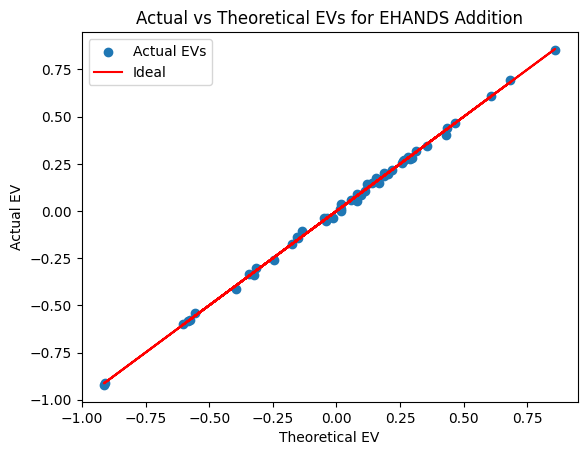

In [9]:
actual_evs = []
theoretical_evs = []

for _ in range(50):
    input_values = (random.uniform(-0.99, 0.99), random.uniform(-0.99, 0.99), random.choice([True, False]))
    #print(f"Testing with input values: {input_values}")
    ev_actual, ev_theory = test_ehands_addition(input_values[0], input_values[1], negation=input_values[2])
    actual_evs.append(ev_actual)
    theoretical_evs.append(ev_theory)

title = 'Actual vs Theoretical EVs for EHANDS Addition'
x_label = 'Theoretical EV'
y_label = 'Actual EV'
legend = 'Actual EVs'
plot_residuals(actual_evs, theoretical_evs, title, x_label, y_label, legend)


## Vertex Classification Setup with QCrank

In [10]:
def configure_qcrank_options(n_shots):
    options = SamplerOptions()
    options.default_shots=n_shots 
    return options

In [23]:
def encode_with_qcrank(data_inp, nq_addr, nq_data, useCZ=False, measure=True, barrier=True):
    qcrankObj = QCrankV2(nq_addr, nq_data, useCZ=useCZ, measure=measure, barrier=barrier)

    qc = qcrankObj.circuit

    qcrankObj.bind_data(data_inp)
    qcEL = qcrankObj.instantiate_circuits()
    return {
        'qc': qc,
        'qcEL': qcEL,
        'nq_addr': nq_addr,
        'nq_data': nq_data,
        'qcrankObj': qcrankObj
    }

In [12]:
def initialize_sample_data():
    n_cubes = 1
    n_data = n_cubes * (2**3)

    nq_addr = math.ceil(math.log2(n_data))
    nq_data = 1

    n_data = 2**nq_addr * nq_data
    data_inp = np.random.uniform(-0.99, 0.99, (n_data, n_cubes))

    return {
        'n_cubes': n_cubes,
        'n_data': n_data,
        'nq_addr': nq_addr,
        'nq_data': nq_data,
        'data_inp': data_inp
    }

In [13]:
def run_sim_job_qcrank(encoding_args, n_cubes, n_shots = 2**8, verbose=False):
    """ 
    Run a quantum circuit on the simulator and return the counts.
    
    :param qc: QuantumCircuit to run
    :param n_shots: Number of shots to run the circuit for
    :param verbose: If True, print the circuit and counts

    :return: Counts of the measurement outcomes
    """
    options = configure_qcrank_options(n_shots)
    sampler = Sampler(mode=sim, options=options)

    job = sampler.run(tuple(encoding_args['qcEL']))
    jobRes = job.result()

    countsL = [jobRes[i].data.c.get_counts() for i in range(n_cubes)]

    if verbose:
        qc = encoding_args['qc']
        cxDepth=qc.depth(filter_function=lambda x: x.operation.name == 'cx')
        print(f'.... PARAMETRIZED CIRCUIT .............. n_cubes={n_cubes}, cx-depth={cxDepth}')
        print('Gates count:', qc.count_ops())
        display(qc.draw('mpl'))


    return countsL

In [14]:
def decode_qcrank_results(encoding_args, data_args, countsL, n_shots):
    qcrankObj = encoding_args['qcrankObj']
    data_rec, data_recErr = qcrankObj.reco_from_yields(countsL)

    for i in range(data_args['n_cubes']):
        print(f'\nCube {i} original data:\n', data_args['data_inp'][..., i].T)
        print(f'Reconstructed data:\n', data_rec[..., i].T)
        print(f'Difference:\n', (data_args['data_inp'][..., i] - data_rec[..., i]).T)
        if i > 2: 
            break

    shpad = n_shots / 2**data_args['nq_addr']
    print(f'Shots per address: {shpad:.1f}, relative error ~ {1/np.sqrt(shpad):.3f}')

    # Analyze residuals
    return analyze_qcrank_residuals(data_args['data_inp'], data_rec)

In [20]:
def marching_qubes_vertex_classification_driver(verbose=False):
    data_args = initialize_sample_data()

    n_shots = data_args['n_data'] * (2**12)
    encoding_args = encode_with_qcrank(data_args['data_inp'], data_args['nq_addr'], data_args['nq_data'], useCZ=False, measure=True, barrier=True)
    
    if verbose:
        print('input data=',data_args['data_inp'].shape,repr(data_args['data_inp']))
    countsL = run_sim_job_qcrank(encoding_args, data_args['n_cubes'], n_shots=n_shots, verbose=verbose)

    return decode_qcrank_results(encoding_args, data_args, countsL, n_shots)
    

In [ ]:
marching_qubes_vertex_classification_driver(True)

In [25]:
def test_qcrank():
    residuals_mean_list = []
    residuals_std_list = []
    correlations_list = []
    
    for i in range(10):
        mean_mean_resid, mean_std_resid, mean_corr = marching_qubes_vertex_classification_driver(False)
        residuals_mean_list.append(mean_mean_resid)
        residuals_std_list.append(mean_std_resid)
        correlations_list.append(mean_corr)
    
    # Plot residual statistics
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Plot 1: Mean residuals across trials
    axes[0].plot(residuals_mean_list, marker='o', label='Mean Residual')
    axes[0].axhline(y=np.mean(residuals_mean_list), color='r', linestyle='--', label=f'Overall Mean: {np.mean(residuals_mean_list):.4f}')
    axes[0].set_xlabel('Trial', fontsize=12)
    axes[0].set_ylabel('Mean Residual', fontsize=12)
    axes[0].set_title('Mean Residuals Across 10 Trials', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Residual standard deviations across trials
    axes[1].plot(residuals_std_list, marker='s', color='green', label='Residual Std Dev')
    axes[1].axhline(y=np.mean(residuals_std_list), color='r', linestyle='--', label=f'Overall Mean: {np.mean(residuals_std_list):.4f}')
    axes[1].set_xlabel('Trial', fontsize=12)
    axes[1].set_ylabel('Std Dev of Residuals', fontsize=12)
    axes[1].set_title('Residual Standard Deviations Across 10 Trials', fontsize=12)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Correlation coefficients across trials
    axes[2].plot(correlations_list, marker='^', color='purple', label='Correlation')
    axes[2].axhline(y=np.mean(correlations_list), color='r', linestyle='--', label=f'Overall Mean: {np.mean(correlations_list):.4f}')
    axes[2].set_xlabel('Trial', fontsize=12)
    axes[2].set_ylabel('Correlation Coefficient', fontsize=12)
    axes[2].set_title('Correlation Coefficients Across 10 Trials', fontsize=12)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim([0.9, 1.0])  # Typical correlation range
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n=== Residual Analysis Summary ===")
    print(f"Mean Residual - Mean: {np.mean(residuals_mean_list):.6f}, Std: {np.std(residuals_mean_list):.6f}")
    print(f"Residual Std Dev - Mean: {np.mean(residuals_std_list):.6f}, Std: {np.std(residuals_std_list):.6f}")
    print(f"Correlation - Mean: {np.mean(correlations_list):.6f}, Std: {np.std(correlations_list):.6f}")


QRFY: nq_addr,nq_data= 3 1  addrBitsL: [1, 2, 3]

Cube 0 original data:
 [-0.00377482 -0.85636079  0.8891654  -0.90775529 -0.80071843  0.04957704
 -0.92054817  0.64946103]
Reconstructed data:
 [[-0.01863659 -0.8664008   0.8993371  -0.90363196 -0.78451014  0.03651753
  -0.92348928  0.65870142]]
Difference:
 [[ 0.01486176  0.86262597 -0.90311192  0.89985714  0.78073531 -0.04029236
   0.91971445 -0.66247625]
 [-0.8377242   0.01004001 -1.75569788  0.04727118 -0.07185065 -0.89287832
   0.06712849 -1.51506221]
 [ 0.90780199  1.7555662  -0.0101717   1.79279736  1.67367554  0.85264787
   1.81265468  0.23046397]
 [-0.8891187  -0.04135449 -1.80709239 -0.00412333 -0.12324515 -0.94427282
   0.01573399 -1.56645671]
 [-0.78208184  0.06568237 -1.70005553  0.10291353 -0.01620829 -0.83723596
   0.12277085 -1.45941985]
 [ 0.06821363  0.91597784 -0.84976006  0.953209    0.83408718  0.01305951
   0.97306632 -0.60912438]
 [-0.90191159 -0.05414738 -1.81988527 -0.01691621 -0.13603803 -0.95706571
   0.0029411

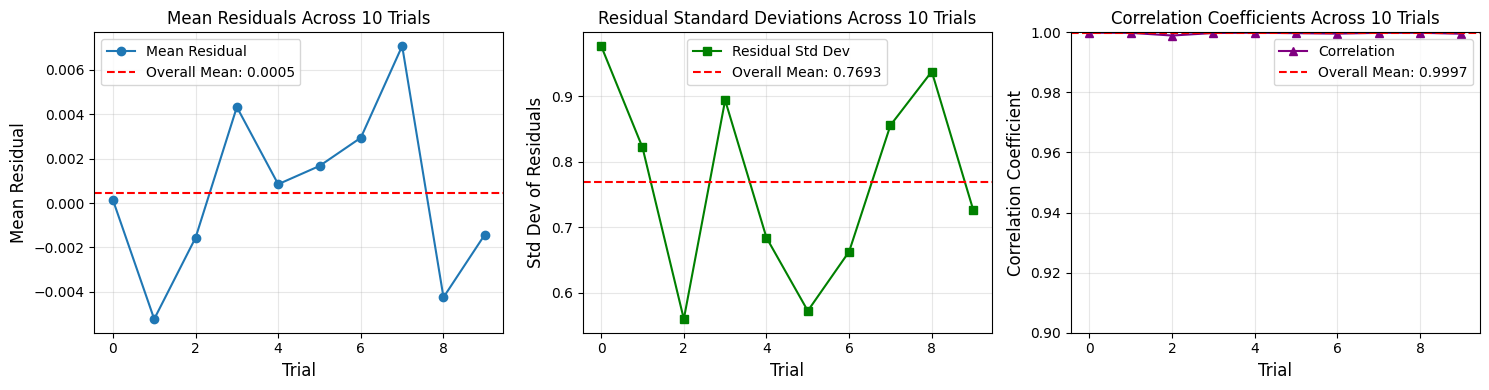


=== Residual Analysis Summary ===
Mean Residual - Mean: 0.000453, Std: 0.003586
Residual Std Dev - Mean: 0.769265, Std: 0.141676
Correlation - Mean: 0.999678, Std: 0.000274


In [26]:
test_qcrank()

## Notes 03/09/26

look into plotting statistical error for binomial distr, make a plot like Chris' (y=actual vs x=expected)

give plot titles

just use a few pre-selected weights, don't need to find the optimal weight

when doing the actual subtraction, try 2 different methods:

- method 1: encode isovalue into array of same length as data, then do elementwise subtraction

- method 2: encode isovalue into the weight of the EHands addition, then do subtraction that way (ask Dr. Bethel for more details)

    - let d[i] = data[i]
    - let t = isolevel
    - step 1: compute NEG(t)
    - step 2: compute weight sum of d[i] + NEG(t) using w = 0.5
    - step 3: multiply step 2 by 2.0

when running tests, the standard number of shots is 4k per data point 

there is some bug possibly in the calculation of EV in get_EV()

how long does circuit get for data size N? (compound metric (1 and multi qubit gates))

## Method 1

In [ ]:
# TODO: encode isovalue into QCrank as an array of length n_data full of the isovalue

## Method 2

In [ ]:
# TODO: encode isovalue into weight of EHands addition using bias qubit